# SpendWise - Longitudinal Dataset Generation

This notebook generates a synthetic longitudinal financial dataset for the SpendWise project.

The cleaned SpendWise dataset contains one financial snapshot per user. Since the SpendWise system needs historical monthly data for future expense prediction, each user will be expanded into 12 monthly financial records.

The longitudinal dataset will contain monthly information for:

- Income
- Food expenses
- Travel expenses
- Entertainment expenses
- Total expense
- Remaining income
- Spending percentages

Each user will have records from January 2025 to December 2025.

The generated dataset will be used in the next stage of the project for ML feature engineering and next-month expense prediction.

> Note: The longitudinal records generated in this notebook are synthetic and are created for academic/project development purposes.

## Import Required Libraries

The required Python libraries are imported for data manipulation, numerical calculations, visualization, and file handling.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

print("Libraries imported successfully.")

Libraries imported successfully.


## Load Cleaned SpendWise Dataset

The cleaned SpendWise dataset is loaded as the base dataset.

This dataset contains the users selected for the SpendWise project and includes their demographic information, financial goals, and primary spending categories.

In [2]:
input_path = "spendwise_cleaned_dataset.csv"

cleaned_df = pd.read_csv(input_path)

print("Dataset loaded successfully.")
print("Shape:", cleaned_df.shape)

display(cleaned_df.head())

Dataset loaded successfully.
Shape: (5706, 19)


,Income,Age,Occupation,City_Tier,Groceries,Transport,Eating_Out,Entertainment,Desired_Savings_Percentage,Desired_Savings,Food_Expense,Travel_Expense,Entertainment_Expense,Total_Expense,Remaining_Income,Remaining_Income_Percentage,Food_Percentage,Travel_Percentage,Entertainment_Percentage
0,50367.605084,35,Student,Tier 3,6313.222081,3221.396403,1513.814376,1723.306926,13.997808,7050.360422,7827.036457,3221.396403,1723.306926,12771.739786,37595.865298,74.642948,61.284027,25.222847,13.493126
1,101455.600247,21,Self-employed/Business,Tier 3,14690.149363,7106.130005,5040.249158,2858.194240,16.455440,16694.965136,19730.398521,7106.130005,2858.194240,29694.722766,71760.877481,70.731312,66.444124,23.930616,9.625260
2,46304.790235,30,Student,Tier 2,5065.627032,2500.054847,2040.310666,1016.613164,12.126401,5615.104745,7105.937697,2500.054847,1016.613164,10622.605708,35682.184527,77.059381,66.894488,23.535232,9.570281
3,20706.822336,31,Student,Tier 3,3037.268327,1459.275062,451.411239,785.289634,8.353299,1729.702763,3488.679566,1459.275062,785.289634,5733.244263,14973.578073,72.312293,60.850008,25.452867,13.697125
4,20668.557390,31,Salaried,Tier 2,2597.398800,1123.038045,878.879491,643.150518,8.245344,1704.193686,3476.278291,1123.038045,643.150518,5242.466854,15426.090536,74.635545,66.309972,21.421939,12.268089


## Inspect Base Dataset

The structure of the cleaned dataset is checked before generating the longitudinal records.

In [3]:
print("Number of rows:", len(cleaned_df))
print("Number of columns:", len(cleaned_df.columns))

print("\nColumns:")
print(cleaned_df.columns.tolist())

print("\nTotal missing values:")
print(cleaned_df.isnull().sum().sum())

Number of rows: 5706
Number of columns: 19

Columns:
['Income', 'Age', 'Occupation', 'City_Tier', 'Groceries', 'Transport', 'Eating_Out', 'Entertainment', 'Desired_Savings_Percentage', 'Desired_Savings', 'Food_Expense', 'Travel_Expense', 'Entertainment_Expense', 'Total_Expense', 'Remaining_Income', 'Remaining_Income_Percentage', 'Food_Percentage', 'Travel_Percentage', 'Entertainment_Percentage']

Total missing values:
0


## Create User ID

A unique User_ID is created for every user.

The same User_ID will be used for all monthly records belonging to that user.

In [4]:
cleaned_df = cleaned_df.copy()

cleaned_df.insert(
    0,
    "User_ID",
    ["U" + str(i).zfill(5) for i in range(1, len(cleaned_df) + 1)]
)

print("User IDs created successfully.")

display(
    cleaned_df[
        [
            "User_ID",
            "Age",
            "Occupation",
            "City_Tier",
            "Income"
        ]
    ].head()
)

User IDs created successfully.


,User_ID,Age,Occupation,City_Tier,Income
0,U00001,35,Student,Tier 3,50367.605084
1,U00002,21,Self-employed/Business,Tier 3,101455.600247
2,U00003,30,Student,Tier 2,46304.790235
3,U00004,31,Student,Tier 3,20706.822336
4,U00005,31,Salaried,Tier 2,20668.557390


## Define Monthly Period

The longitudinal dataset will contain 12 monthly records for every user.

The selected period is January 2025 to December 2025.

In [5]:
months = pd.date_range(
    start="2025-01-01",
    end="2025-12-01",
    freq="MS"
)

print("Number of months:", len(months))

print("\nMonthly period:")
print(months)

Number of months: 12

Monthly period:
DatetimeIndex(['2025-01-01', '2025-02-01', '2025-03-01', '2025-04-01',
               '2025-05-01', '2025-06-01', '2025-07-01', '2025-08-01',
               '2025-09-01', '2025-10-01', '2025-11-01', '2025-12-01'],
              dtype='datetime64[us]', freq='MS')


## Expand Users to 12 Monthly Records

Each user is expanded into 12 monthly records.

With 5,706 users and 12 months per user, the resulting dataset will contain:

5,706 × 12 = 68,472 records.

In [6]:
longitudinal_df = cleaned_df.loc[
    cleaned_df.index.repeat(len(months))
].reset_index(drop=True)

longitudinal_df["Month"] = np.tile(
    months,
    len(cleaned_df)
)

longitudinal_df["Month_Number"] = (
    longitudinal_df["Month"].dt.month
)

print("Longitudinal dataset created.")

print("Shape:", longitudinal_df.shape)

display(
    longitudinal_df[
        [
            "User_ID",
            "Month",
            "Month_Number",
            "Age",
            "Occupation"
        ]
    ].head(15)
)

Longitudinal dataset created.
Shape: (68472, 22)


,User_ID,Month,Month_Number,Age,Occupation
0,U00001,2025-01-01,1,35,Student
1,U00001,2025-02-01,2,35,Student
2,U00001,2025-03-01,3,35,Student
3,U00001,2025-04-01,4,35,Student
4,U00001,2025-05-01,5,35,Student
5,U00001,2025-06-01,6,35,Student
6,U00001,2025-07-01,7,35,Student
7,U00001,2025-08-01,8,35,Student
8,U00001,2025-09-01,9,35,Student
9,U00001,2025-10-01,10,35,Student


## Create Quarter Feature

The month is converted into a quarterly representation.

This feature can help the ML model identify broader seasonal patterns.

In [7]:
longitudinal_df["Quarter"] = (
    "Q" + longitudinal_df["Month"].dt.quarter.astype(str)
)

display(
    longitudinal_df[
        [
            "Month",
            "Month_Number",
            "Quarter"
        ]
    ].drop_duplicates().sort_values("Month")
)

,Month,Month_Number,Quarter
0,2025-01-01,1,Q1
1,2025-02-01,2,Q1
2,2025-03-01,3,Q1
3,2025-04-01,4,Q2
4,2025-05-01,5,Q2
5,2025-06-01,6,Q2
6,2025-07-01,7,Q3
7,2025-08-01,8,Q3
8,2025-09-01,9,Q3
9,2025-10-01,10,Q4


## Generate Monthly Income

Monthly income is generated from each user's baseline income.

Controlled variation is introduced so that the income is not identical across all 12 months.

The variation is different for each occupation:

- Student: relatively stable
- Salaried: highly stable
- Self-employed/Business: comparatively more variable

The generated values are synthetic.

In [8]:
np.random.seed(42)

occupation_income_variation = {
    "Student": 0.03,
    "Salaried": 0.02,
    "Self-employed/Business": 0.08
}

income_variation = (
    longitudinal_df["Occupation"]
    .map(occupation_income_variation)
    .fillna(0.05)
)

income_trend = (
    1 + ((longitudinal_df["Month_Number"] - 1) * 0.002)
)

income_random = np.random.normal(
    loc=0,
    scale=1,
    size=len(longitudinal_df)
)

longitudinal_df["Monthly_Income"] = (
    longitudinal_df["Income"]
    * income_trend
    * (
        1
        + income_random * income_variation
    )
)

longitudinal_df["Monthly_Income"] = (
    longitudinal_df["Monthly_Income"].clip(lower=0)
)

print("Monthly income generated successfully.")

display(
    longitudinal_df[
        [
            "User_ID",
            "Month",
            "Income",
            "Monthly_Income"
        ]
    ].head(12)
)

Monthly income generated successfully.


,User_ID,Month,Income,Monthly_Income
0,U00001,2025-01-01,50367.605084,51118.154153
1,U00001,2025-02-01,50367.605084,50259.001200
2,U00001,2025-03-01,50367.605084,51551.665821
3,U00001,2025-04-01,50367.605084,52984.959750
4,U00001,2025-05-01,50367.605084,50413.903084
5,U00001,2025-06-01,50367.605084,50513.955726
6,U00001,2025-07-01,50367.605084,53386.886188
7,U00001,2025-08-01,50367.605084,52248.601652
8,U00001,2025-09-01,50367.605084,50452.747527
9,U00001,2025-10-01,50367.605084,52108.802298


## Generate Monthly Food Expense

Monthly Food expense is generated from the user's baseline Food_Expense.

Controlled monthly variation is introduced along with mild seasonal variation.

The generated values are synthetic.

In [9]:
food_seasonality = {
    1: 1.00,
    2: 0.98,
    3: 1.01,
    4: 1.00,
    5: 1.02,
    6: 1.03,
    7: 1.01,
    8: 1.00,
    9: 1.02,
    10: 1.04,
    11: 1.05,
    12: 1.08
}

food_random = np.random.normal(
    loc=0,
    scale=0.05,
    size=len(longitudinal_df)
)

longitudinal_df["Monthly_Food_Expense"] = (
    longitudinal_df["Food_Expense"]
    * longitudinal_df["Month_Number"].map(food_seasonality)
    * (1 + food_random)
)

longitudinal_df["Monthly_Food_Expense"] = (
    longitudinal_df["Monthly_Food_Expense"].clip(lower=0)
)

print("Monthly Food expense generated successfully.")

display(
    longitudinal_df[
        [
            "User_ID",
            "Month",
            "Food_Expense",
            "Monthly_Food_Expense"
        ]
    ].head(12)
)

Monthly Food expense generated successfully.


,User_ID,Month,Food_Expense,Monthly_Food_Expense
0,U00001,2025-01-01,7827.036457,7251.489712
1,U00001,2025-02-01,7827.036457,8103.568331
2,U00001,2025-03-01,7827.036457,7349.302806
3,U00001,2025-04-01,7827.036457,8248.640275
4,U00001,2025-05-01,7827.036457,7970.677730
5,U00001,2025-06-01,7827.036457,7701.617573
6,U00001,2025-07-01,7827.036457,8635.917018
7,U00001,2025-08-01,7827.036457,7985.623806
8,U00001,2025-09-01,7827.036457,8468.472742
9,U00001,2025-10-01,7827.036457,8316.185462


## Generate Monthly Travel Expense

Monthly Travel expense is generated from the user's baseline Travel_Expense.

Travel spending is given slightly more monthly variation than Food spending.

The generated values are synthetic.

In [10]:
travel_seasonality = {
    1: 1.00,
    2: 0.98,
    3: 1.02,
    4: 1.00,
    5: 1.03,
    6: 1.05,
    7: 1.04,
    8: 1.02,
    9: 1.00,
    10: 1.04,
    11: 1.06,
    12: 1.10
}

travel_random = np.random.normal(
    loc=0,
    scale=0.08,
    size=len(longitudinal_df)
)

longitudinal_df["Monthly_Travel_Expense"] = (
    longitudinal_df["Travel_Expense"]
    * longitudinal_df["Month_Number"].map(travel_seasonality)
    * (1 + travel_random)
)

longitudinal_df["Monthly_Travel_Expense"] = (
    longitudinal_df["Monthly_Travel_Expense"].clip(lower=0)
)

print("Monthly Travel expense generated successfully.")

display(
    longitudinal_df[
        [
            "User_ID",
            "Month",
            "Travel_Expense",
            "Monthly_Travel_Expense"
        ]
    ].head(12)
)

Monthly Travel expense generated successfully.


,User_ID,Month,Travel_Expense,Monthly_Travel_Expense
0,U00001,2025-01-01,3221.396403,2959.538900
1,U00001,2025-02-01,3221.396403,3395.485059
2,U00001,2025-03-01,3221.396403,3774.737040
3,U00001,2025-04-01,3221.396403,3456.150563
4,U00001,2025-05-01,3221.396403,3168.358214
5,U00001,2025-06-01,3221.396403,3623.076110
6,U00001,2025-07-01,3221.396403,2962.844434
7,U00001,2025-08-01,3221.396403,2933.883487
8,U00001,2025-09-01,3221.396403,3446.852726
9,U00001,2025-10-01,3221.396403,3280.512366


## Generate Monthly Entertainment Expense

Monthly Entertainment expense is generated from the user's baseline Entertainment_Expense.

Controlled monthly variation and mild seasonal variation are introduced.

The generated values are synthetic.

In [11]:
entertainment_seasonality = {
    1: 0.98,
    2: 0.98,
    3: 1.00,
    4: 1.00,
    5: 1.02,
    6: 1.02,
    7: 1.03,
    8: 1.02,
    9: 1.03,
    10: 1.05,
    11: 1.08,
    12: 1.12
}

entertainment_random = np.random.normal(
    loc=0,
    scale=0.07,
    size=len(longitudinal_df)
)

longitudinal_df["Monthly_Entertainment_Expense"] = (
    longitudinal_df["Entertainment_Expense"]
    * longitudinal_df["Month_Number"].map(
        entertainment_seasonality
    )
    * (1 + entertainment_random)
)

longitudinal_df["Monthly_Entertainment_Expense"] = (
    longitudinal_df["Monthly_Entertainment_Expense"].clip(lower=0)
)

print("Monthly Entertainment expense generated successfully.")

display(
    longitudinal_df[
        [
            "User_ID",
            "Month",
            "Entertainment_Expense",
            "Monthly_Entertainment_Expense"
        ]
    ].head(12)
)

Monthly Entertainment expense generated successfully.


,User_ID,Month,Entertainment_Expense,Monthly_Entertainment_Expense
0,U00001,2025-01-01,1723.306926,1571.342825
1,U00001,2025-02-01,1723.306926,1788.395595
2,U00001,2025-03-01,1723.306926,1836.716315
3,U00001,2025-04-01,1723.306926,1777.494609
4,U00001,2025-05-01,1723.306926,1512.602949
5,U00001,2025-06-01,1723.306926,1583.880561
6,U00001,2025-07-01,1723.306926,1653.988152
7,U00001,2025-08-01,1723.306926,1629.889800
8,U00001,2025-09-01,1723.306926,1697.009474
9,U00001,2025-10-01,1723.306926,1865.677840


## Replace Baseline Values with Generated Monthly Values

The generated monthly values are assigned to the main financial columns.

The temporary monthly columns are then removed.

This prevents duplicate column names and ensures that the final dataset contains the generated monthly values.

In [12]:
longitudinal_df["Income"] = (
    longitudinal_df["Monthly_Income"]
)

longitudinal_df["Food_Expense"] = (
    longitudinal_df["Monthly_Food_Expense"]
)

longitudinal_df["Travel_Expense"] = (
    longitudinal_df["Monthly_Travel_Expense"]
)

longitudinal_df["Entertainment_Expense"] = (
    longitudinal_df["Monthly_Entertainment_Expense"]
)

longitudinal_df = longitudinal_df.drop(
    columns=[
        "Monthly_Income",
        "Monthly_Food_Expense",
        "Monthly_Travel_Expense",
        "Monthly_Entertainment_Expense"
    ]
)

print("Monthly financial values assigned successfully.")

display(
    longitudinal_df[
        [
            "User_ID",
            "Month",
            "Income",
            "Food_Expense",
            "Travel_Expense",
            "Entertainment_Expense"
        ]
    ].head(12)
)

Monthly financial values assigned successfully.


,User_ID,Month,Income,Food_Expense,Travel_Expense,Entertainment_Expense
0,U00001,2025-01-01,51118.154153,7251.489712,2959.538900,1571.342825
1,U00001,2025-02-01,50259.001200,8103.568331,3395.485059,1788.395595
2,U00001,2025-03-01,51551.665821,7349.302806,3774.737040,1836.716315
3,U00001,2025-04-01,52984.959750,8248.640275,3456.150563,1777.494609
4,U00001,2025-05-01,50413.903084,7970.677730,3168.358214,1512.602949
5,U00001,2025-06-01,50513.955726,7701.617573,3623.076110,1583.880561
6,U00001,2025-07-01,53386.886188,8635.917018,2962.844434,1653.988152
7,U00001,2025-08-01,52248.601652,7985.623806,2933.883487,1629.889800
8,U00001,2025-09-01,50452.747527,8468.472742,3446.852726,1697.009474
9,U00001,2025-10-01,52108.802298,8316.185462,3280.512366,1865.677840


## Verify Monthly Variation

The average income and spending values are calculated for each month.

This confirms that the longitudinal dataset contains actual month-to-month variation rather than identical values across all months.

In [13]:
monthly_check = (
    longitudinal_df
    .groupby("Month_Number")[
        [
            "Income",
            "Food_Expense",
            "Travel_Expense",
            "Entertainment_Expense"
        ]
    ]
    .mean()
    .round(2)
)

display(monthly_check)

,Income,Food_Expense,Travel_Expense,Entertainment_Expense
Month_Number,,,,
1,42266.79,6766.53,2752.62,1439.00
2,42218.89,6619.54,2690.44,1438.38
3,42417.41,6827.16,2802.54,1463.59
4,42468.38,6754.05,2744.70,1470.85
5,42597.39,6887.79,2832.66,1497.18
6,42707.79,6953.26,2879.82,1498.95
7,42794.50,6827.56,2864.62,1514.88
8,42790.77,6755.84,2801.74,1499.77
9,42858.48,6891.91,2743.57,1513.60


## Calculate Total Monthly Expense

Total monthly expense is calculated as the sum of Food, Travel, and Entertainment expenses.

This is the primary spending measure that SpendWise will use for future expense prediction.

In [14]:
longitudinal_df["Total_Expense"] = (
    longitudinal_df["Food_Expense"]
    + longitudinal_df["Travel_Expense"]
    + longitudinal_df["Entertainment_Expense"]
)

display(
    longitudinal_df[
        [
            "User_ID",
            "Month",
            "Food_Expense",
            "Travel_Expense",
            "Entertainment_Expense",
            "Total_Expense"
        ]
    ].head(12)
)

,User_ID,Month,Food_Expense,Travel_Expense,Entertainment_Expense,Total_Expense
0,U00001,2025-01-01,7251.489712,2959.538900,1571.342825,11782.371437
1,U00001,2025-02-01,8103.568331,3395.485059,1788.395595,13287.448984
2,U00001,2025-03-01,7349.302806,3774.737040,1836.716315,12960.756161
3,U00001,2025-04-01,8248.640275,3456.150563,1777.494609,13482.285447
4,U00001,2025-05-01,7970.677730,3168.358214,1512.602949,12651.638892
5,U00001,2025-06-01,7701.617573,3623.076110,1583.880561,12908.574244
6,U00001,2025-07-01,8635.917018,2962.844434,1653.988152,13252.749604
7,U00001,2025-08-01,7985.623806,2933.883487,1629.889800,12549.397093
8,U00001,2025-09-01,8468.472742,3446.852726,1697.009474,13612.334942
9,U00001,2025-10-01,8316.185462,3280.512366,1865.677840,13462.375667


## Calculate Spending Category Percentages

The percentage contribution of each spending category to total monthly expense is calculated.

These features describe the user's monthly spending pattern.

In [15]:
longitudinal_df["Food_Percentage"] = np.where(
    longitudinal_df["Total_Expense"] > 0,
    longitudinal_df["Food_Expense"]
    / longitudinal_df["Total_Expense"] * 100,
    0
)

longitudinal_df["Travel_Percentage"] = np.where(
    longitudinal_df["Total_Expense"] > 0,
    longitudinal_df["Travel_Expense"]
    / longitudinal_df["Total_Expense"] * 100,
    0
)

longitudinal_df["Entertainment_Percentage"] = np.where(
    longitudinal_df["Total_Expense"] > 0,
    longitudinal_df["Entertainment_Expense"]
    / longitudinal_df["Total_Expense"] * 100,
    0
)

display(
    longitudinal_df[
        [
            "User_ID",
            "Month",
            "Food_Percentage",
            "Travel_Percentage",
            "Entertainment_Percentage"
        ]
    ].head(12)
)

,User_ID,Month,Food_Percentage,Travel_Percentage,Entertainment_Percentage
0,U00001,2025-01-01,61.545248,25.118364,13.336388
1,U00001,2025-02-01,60.986637,25.554078,13.459285
2,U00001,2025-03-01,56.704275,29.124358,14.171367
3,U00001,2025-04-01,61.181321,25.634753,13.183927
4,U00001,2025-05-01,63.001148,25.043065,11.955787
5,U00001,2025-06-01,59.662806,28.067206,12.269988
6,U00001,2025-07-01,65.163210,22.356451,12.480340
7,U00001,2025-08-01,63.633526,23.378681,12.987794
8,U00001,2025-09-01,62.211757,25.321539,12.466704
9,U00001,2025-10-01,61.773536,24.368005,13.858459


## Calculate Remaining Income

Remaining income represents the amount of monthly income left after accounting for Food, Travel, and Entertainment expenses.

The remaining income percentage is also calculated relative to monthly income.

In [16]:
longitudinal_df["Remaining_Income"] = (
    longitudinal_df["Income"]
    - longitudinal_df["Total_Expense"]
)

longitudinal_df["Remaining_Income_Percentage"] = np.where(
    longitudinal_df["Income"] > 0,
    longitudinal_df["Remaining_Income"]
    / longitudinal_df["Income"] * 100,
    0
)

display(
    longitudinal_df[
        [
            "User_ID",
            "Month",
            "Income",
            "Total_Expense",
            "Remaining_Income",
            "Remaining_Income_Percentage"
        ]
    ].head(12)
)

,User_ID,Month,Income,Total_Expense,Remaining_Income,Remaining_Income_Percentage
0,U00001,2025-01-01,51118.154153,11782.371437,39335.782715,76.950710
1,U00001,2025-02-01,50259.001200,13287.448984,36971.552216,73.562051
2,U00001,2025-03-01,51551.665821,12960.756161,38590.909661,74.858705
3,U00001,2025-04-01,52984.959750,13482.285447,39502.674303,74.554505
4,U00001,2025-05-01,50413.903084,12651.638892,37762.264192,74.904465
5,U00001,2025-06-01,50513.955726,12908.574244,37605.381482,74.445529
6,U00001,2025-07-01,53386.886188,13252.749604,40134.136584,75.176021
7,U00001,2025-08-01,52248.601652,12549.397093,39699.204560,75.981372
8,U00001,2025-09-01,50452.747527,13612.334942,36840.412584,73.019636
9,U00001,2025-10-01,52108.802298,13462.375667,38646.426631,74.164872


## Inspect Monthly History for One User

A single user's 12-month financial history is inspected to verify that the longitudinal data has been generated correctly.

The financial values should vary across the months.

In [17]:
sample_user = longitudinal_df["User_ID"].iloc[0]

user_history = (
    longitudinal_df[
        longitudinal_df["User_ID"] == sample_user
    ][
        [
            "User_ID",
            "Month",
            "Income",
            "Food_Expense",
            "Travel_Expense",
            "Entertainment_Expense",
            "Total_Expense",
            "Remaining_Income"
        ]
    ]
    .sort_values("Month")
)

display(user_history)

,User_ID,Month,Income,Food_Expense,Travel_Expense,Entertainment_Expense,Total_Expense,Remaining_Income
0,U00001,2025-01-01,51118.154153,7251.489712,2959.538900,1571.342825,11782.371437,39335.782715
1,U00001,2025-02-01,50259.001200,8103.568331,3395.485059,1788.395595,13287.448984,36971.552216
2,U00001,2025-03-01,51551.665821,7349.302806,3774.737040,1836.716315,12960.756161,38590.909661
3,U00001,2025-04-01,52984.959750,8248.640275,3456.150563,1777.494609,13482.285447,39502.674303
4,U00001,2025-05-01,50413.903084,7970.677730,3168.358214,1512.602949,12651.638892,37762.264192
5,U00001,2025-06-01,50513.955726,7701.617573,3623.076110,1583.880561,12908.574244,37605.381482
6,U00001,2025-07-01,53386.886188,8635.917018,2962.844434,1653.988152,13252.749604,40134.136584
7,U00001,2025-08-01,52248.601652,7985.623806,2933.883487,1629.889800,12549.397093,39699.204560
8,U00001,2025-09-01,50452.747527,8468.472742,3446.852726,1697.009474,13612.334942,36840.412584
9,U00001,2025-10-01,52108.802298,8316.185462,3280.512366,1865.677840,13462.375667,38646.426631


## Validate Records per User

Every user should have exactly 12 monthly records.

In [19]:
records_per_user = (
    longitudinal_df
    .groupby("User_ID")
    .size()
)

print(records_per_user.value_counts())


12    5706
Name: count, dtype: int64


## Check Missing Values

The longitudinal dataset is checked for missing values across all columns.

In [20]:
missing_values = longitudinal_df.isnull().sum()

print(missing_values[missing_values > 0])

print(
    "Total missing values:",
    longitudinal_df.isnull().sum().sum()
)

Series([], dtype: int64)
Total missing values: 0


## Check Negative Financial Values

All generated income and expense values are checked to ensure that no negative financial values were generated.

In [21]:
financial_columns = [
    "Income",
    "Food_Expense",
    "Travel_Expense",
    "Entertainment_Expense",
    "Total_Expense"
]

negative_values = (
    longitudinal_df[financial_columns] < 0
).sum()

print(negative_values)

print(
    "Total negative financial values:",
    negative_values.sum()
)

Income                   0
Food_Expense             0
Travel_Expense           0
Entertainment_Expense    0
Total_Expense            0
dtype: int64
Total negative financial values: 0


## Validate Total Expense Calculation

The Total_Expense column is verified against the sum of Food, Travel, and Entertainment expenses.

In [22]:
calculated_total = (
    longitudinal_df["Food_Expense"]
    + longitudinal_df["Travel_Expense"]
    + longitudinal_df["Entertainment_Expense"]
)

total_difference = (
    longitudinal_df["Total_Expense"]
    - calculated_total
).abs()

print(
    "Maximum difference:",
    total_difference.max()
)

Maximum difference: 0.0


## Validate Spending Percentages

The Food, Travel, and Entertainment percentages should add up to approximately 100% for records where Total_Expense is greater than zero.

In [23]:
percentage_sum = (
    longitudinal_df["Food_Percentage"]
    + longitudinal_df["Travel_Percentage"]
    + longitudinal_df["Entertainment_Percentage"]
)

percentage_difference = np.where(
    longitudinal_df["Total_Expense"] > 0,
    abs(percentage_sum - 100),
    0
)

print(
    "Maximum percentage difference:",
    percentage_difference.max()
)

Maximum percentage difference: 2.842170943040401e-14


## Statistical Summary of Monthly Financial Data

Descriptive statistics are generated for the main monthly financial variables.

In [24]:
financial_summary = (
    longitudinal_df[
        [
            "Income",
            "Food_Expense",
            "Travel_Expense",
            "Entertainment_Expense",
            "Total_Expense",
            "Remaining_Income"
        ]
    ]
    .describe()
    .round(2)
)

display(financial_summary)

,Income,Food_Expense,Travel_Expense,Entertainment_Expense,Total_Expense,Remaining_Income
count,68472.00,68472.00,68472.00,68472.00,68472.00,68472.00
mean,42694.83,6892.21,2825.34,1509.39,11226.94,31467.89
std,44337.15,7019.84,3060.05,1651.74,11559.85,32933.42
min,1178.45,205.32,88.36,43.70,362.27,783.55
25%,17551.35,2779.99,1129.67,583.35,4566.24,12838.40
50%,30328.72,4869.66,1975.85,1041.54,7938.07,22333.55
75%,52359.49,8517.65,3443.17,1852.68,13843.47,38526.04
max,1133041.62,162007.07,94416.82,45627.33,289665.45,861553.15


## Distribution of Total Monthly Expense

A histogram is used to visualize the distribution of total monthly spending across all users and months.

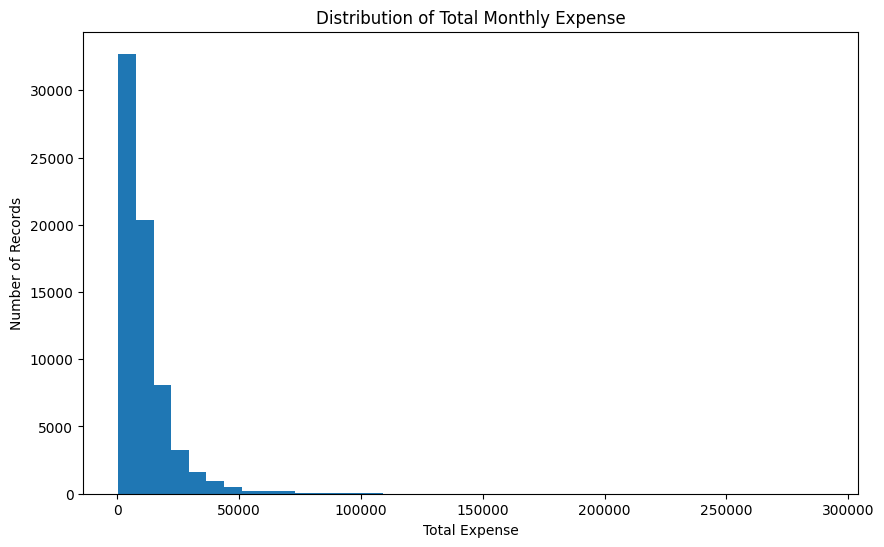

In [25]:
plt.figure(figsize=(10, 6))

plt.hist(
    longitudinal_df["Total_Expense"],
    bins=40
)

plt.title("Distribution of Total Monthly Expense")
plt.xlabel("Total Expense")
plt.ylabel("Number of Records")

plt.show()

## Average Monthly Spending

The average income and expense values are calculated for each month.

This helps verify that the generated longitudinal dataset contains meaningful monthly variation.

In [26]:
monthly_summary = (
    longitudinal_df
    .groupby("Month_Number")[
        [
            "Income",
            "Food_Expense",
            "Travel_Expense",
            "Entertainment_Expense",
            "Total_Expense"
        ]
    ]
    .mean()
    .round(2)
)

display(monthly_summary)

,Income,Food_Expense,Travel_Expense,Entertainment_Expense,Total_Expense
Month_Number,,,,,
1,42266.79,6766.53,2752.62,1439.00,10958.16
2,42218.89,6619.54,2690.44,1438.38,10748.36
3,42417.41,6827.16,2802.54,1463.59,11093.29
4,42468.38,6754.05,2744.70,1470.85,10969.61
5,42597.39,6887.79,2832.66,1497.18,11217.63
6,42707.79,6953.26,2879.82,1498.95,11332.04
7,42794.50,6827.56,2864.62,1514.88,11207.06
8,42790.77,6755.84,2801.74,1499.77,11057.35
9,42858.48,6891.91,2743.57,1513.60,11149.08


## Monthly Average Total Expense

The average total expense for each month is visualized to observe the overall monthly spending pattern.

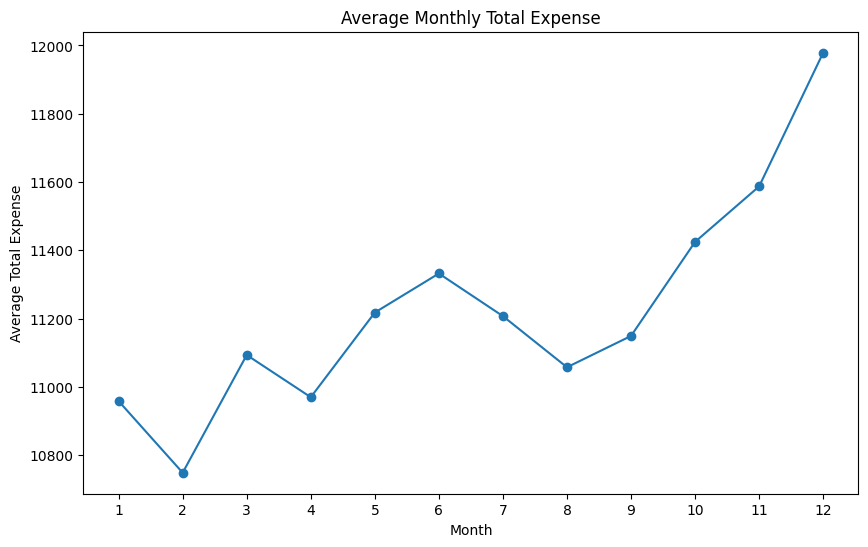

In [27]:
plt.figure(figsize=(10, 6))

plt.plot(
    monthly_summary.index,
    monthly_summary["Total_Expense"],
    marker="o"
)

plt.title("Average Monthly Total Expense")
plt.xlabel("Month")
plt.ylabel("Average Total Expense")
plt.xticks(range(1, 13))

plt.show()

## Create Final Longitudinal Dataset

The final dataset is restricted to the required 19 columns.

The final dataset contains user information, financial goals, monthly information, monthly income, primary spending categories, total expense, remaining income, and spending percentages.

In [28]:
final_columns = [
    "User_ID",
    "Age",
    "Occupation",
    "City_Tier",
    "Desired_Savings_Percentage",
    "Desired_Savings",
    "Month",
    "Month_Number",
    "Quarter",
    "Income",
    "Food_Expense",
    "Travel_Expense",
    "Entertainment_Expense",
    "Total_Expense",
    "Remaining_Income",
    "Remaining_Income_Percentage",
    "Food_Percentage",
    "Travel_Percentage",
    "Entertainment_Percentage"
]

longitudinal_df = longitudinal_df[
    final_columns
].copy()

print("Final dataset shape:", longitudinal_df.shape)
print("Number of columns:", len(longitudinal_df.columns))

Final dataset shape: (68472, 19)
Number of columns: 19


## Preview Final Longitudinal Dataset

The first few records of the final dataset are displayed for a final structural check.

In [29]:
display(
    longitudinal_df.head(10)
)

,User_ID,Age,Occupation,City_Tier,Desired_Savings_Percentage,Desired_Savings,Month,Month_Number,Quarter,Income,Food_Expense,Travel_Expense,Entertainment_Expense,Total_Expense,Remaining_Income,Remaining_Income_Percentage,Food_Percentage,Travel_Percentage,Entertainment_Percentage
0,U00001,35,Student,Tier 3,13.997808,7050.360422,2025-01-01,1,Q1,51118.154153,7251.489712,2959.538900,1571.342825,11782.371437,39335.782715,76.950710,61.545248,25.118364,13.336388
1,U00001,35,Student,Tier 3,13.997808,7050.360422,2025-02-01,2,Q1,50259.001200,8103.568331,3395.485059,1788.395595,13287.448984,36971.552216,73.562051,60.986637,25.554078,13.459285
2,U00001,35,Student,Tier 3,13.997808,7050.360422,2025-03-01,3,Q1,51551.665821,7349.302806,3774.737040,1836.716315,12960.756161,38590.909661,74.858705,56.704275,29.124358,14.171367
3,U00001,35,Student,Tier 3,13.997808,7050.360422,2025-04-01,4,Q2,52984.959750,8248.640275,3456.150563,1777.494609,13482.285447,39502.674303,74.554505,61.181321,25.634753,13.183927
4,U00001,35,Student,Tier 3,13.997808,7050.360422,2025-05-01,5,Q2,50413.903084,7970.677730,3168.358214,1512.602949,12651.638892,37762.264192,74.904465,63.001148,25.043065,11.955787
5,U00001,35,Student,Tier 3,13.997808,7050.360422,2025-06-01,6,Q2,50513.955726,7701.617573,3623.076110,1583.880561,12908.574244,37605.381482,74.445529,59.662806,28.067206,12.269988
6,U00001,35,Student,Tier 3,13.997808,7050.360422,2025-07-01,7,Q3,53386.886188,8635.917018,2962.844434,1653.988152,13252.749604,40134.136584,75.176021,65.163210,22.356451,12.480340
7,U00001,35,Student,Tier 3,13.997808,7050.360422,2025-08-01,8,Q3,52248.601652,7985.623806,2933.883487,1629.889800,12549.397093,39699.204560,75.981372,63.633526,23.378681,12.987794
8,U00001,35,Student,Tier 3,13.997808,7050.360422,2025-09-01,9,Q3,50452.747527,8468.472742,3446.852726,1697.009474,13612.334942,36840.412584,73.019636,62.211757,25.321539,12.466704
9,U00001,35,Student,Tier 3,13.997808,7050.360422,2025-10-01,10,Q4,52108.802298,8316.185462,3280.512366,1865.677840,13462.375667,38646.426631,74.164872,61.773536,24.368005,13.858459


## Final Dataset Validation

The final longitudinal dataset is validated for:

- Number of unique users
- Total records
- Number of columns
- Records per user
- Missing values
- Negative financial values
- Date range

In [30]:
print("=" * 70)
print("SPENDWISE LONGITUDINAL DATASET VALIDATION")
print("=" * 70)

print(
    "Unique users:",
    longitudinal_df["User_ID"].nunique()
)

print(
    "Total records:",
    len(longitudinal_df)
)

print(
    "Columns:",
    len(longitudinal_df.columns)
)

records_per_user = (
    longitudinal_df
    .groupby("User_ID")
    .size()
    .unique()
)

print(
    "Records per user:",
    sorted(records_per_user)
)

print(
    "Missing values:",
    longitudinal_df.isnull().sum().sum()
)

financial_columns = [
    "Income",
    "Food_Expense",
    "Travel_Expense",
    "Entertainment_Expense",
    "Total_Expense",
    "Remaining_Income"
]

negative_financial_values = (
    longitudinal_df[financial_columns] < 0
).sum().sum()

print(
    "Negative financial values:",
    negative_financial_values
)

print(
    "Date range:",
    longitudinal_df["Month"].min(),
    "to",
    longitudinal_df["Month"].max()
)

print("=" * 70)

SPENDWISE LONGITUDINAL DATASET VALIDATION
Unique users: 5706
Total records: 68472
Columns: 19
Records per user: [np.int64(12)]
Missing values: 0
Negative financial values: 0
Date range: 2025-01-01 00:00:00 to 2025-12-01 00:00:00


## Save Longitudinal Dataset

The validated longitudinal dataset is saved as a CSV file.

This file will be used in the next stage of the SpendWise ML pipeline for feature engineering and next-month expense prediction.

In [31]:

output_path = "spendwise_longitudinal_dataset.csv"

longitudinal_df.to_csv(
    output_path,
    index=False
)

print("Longitudinal dataset saved successfully.")
print("File:", output_path)
print("Shape:", longitudinal_df.shape)

Longitudinal dataset saved successfully.
File: spendwise_longitudinal_dataset.csv
Shape: (68472, 19)


## Conclusion

The SpendWise longitudinal dataset has been successfully generated from the cleaned user dataset.

Each user has 12 monthly financial records covering January 2025 to December 2025.

The final dataset contains:

- User information
- Financial goals
- Monthly income
- Food expenses
- Travel expenses
- Entertainment expenses
- Total monthly expense
- Remaining income
- Spending percentages
- Month and quarter information

The final dataset contains 68,472 records and 19 columns.

The dataset has been saved as:
spendwise_longitudinal_dataset.csv

This dataset will be used in the next stage of the SpendWise project for ML feature engineering and next-month expense prediction.

> Note: The longitudinal records are synthetic and are intended for academic/project development purposes.

In [32]:
# ============================================================
# 1. FINAL SHAPE AND COLUMNS
# ============================================================

print("=" * 70)
print("1. FINAL SHAPE AND COLUMNS")
print("=" * 70)

print("Shape:", longitudinal_df.shape)

print("\nColumns:")
print(longitudinal_df.columns.tolist())


# ============================================================
# 2. BASIC DATASET INFORMATION
# ============================================================

print("\n" + "=" * 70)
print("2. BASIC DATASET INFORMATION")
print("=" * 70)

longitudinal_df.info()


# ============================================================
# 3. MISSING VALUES
# ============================================================

print("\n" + "=" * 70)
print("3. MISSING VALUES")
print("=" * 70)

print(longitudinal_df.isnull().sum())


# ============================================================
# 4. UNIQUE USERS AND RECORDS PER USER
# ============================================================

print("\n" + "=" * 70)
print("4. UNIQUE USERS AND RECORDS PER USER")
print("=" * 70)

print(
    "Unique users:",
    longitudinal_df["User_ID"].nunique()
)

print("\nRecords per user:")

print(
    longitudinal_df
    .groupby("User_ID")
    .size()
    .value_counts()
    .sort_index()
)


# ============================================================
# 5. DATE / MONTH CHECK
# ============================================================

print("\n" + "=" * 70)
print("5. DATE / MONTH CHECK")
print("=" * 70)

print(
    "Minimum month:",
    longitudinal_df["Month"].min()
)

print(
    "Maximum month:",
    longitudinal_df["Month"].max()
)

print(
    "\nNumber of unique months:",
    longitudinal_df["Month"].nunique()
)

print("\nMonths:")

print(
    longitudinal_df["Month"]
    .drop_duplicates()
    .sort_values()
    .tolist()
)


# ============================================================
# 6. DUPLICATE USER + MONTH CHECK
# ============================================================

print("\n" + "=" * 70)
print("6. DUPLICATE USER + MONTH CHECK")
print("=" * 70)

duplicate_user_months = (
    longitudinal_df
    .duplicated(
        subset=["User_ID", "Month"]
    )
    .sum()
)

print(
    "Duplicate User_ID + Month records:",
    duplicate_user_months
)


# ============================================================
# 7. NEGATIVE FINANCIAL VALUES
# ============================================================

print("\n" + "=" * 70)
print("7. NEGATIVE FINANCIAL VALUES")
print("=" * 70)

financial_columns = [
    "Income",
    "Food_Expense",
    "Travel_Expense",
    "Entertainment_Expense",
    "Total_Expense",
    "Remaining_Income"
]

print(
    longitudinal_df[financial_columns].min()
)


# ============================================================
# 8. TOTAL EXPENSE VALIDATION
# ============================================================

print("\n" + "=" * 70)
print("8. TOTAL EXPENSE VALIDATION")
print("=" * 70)

total_check = (
    longitudinal_df["Food_Expense"]
    + longitudinal_df["Travel_Expense"]
    + longitudinal_df["Entertainment_Expense"]
)

total_difference = (
    longitudinal_df["Total_Expense"]
    - total_check
).abs()

print(
    "Maximum Total_Expense difference:",
    total_difference.max()
)


# ============================================================
# 9. SPENDING PERCENTAGE VALIDATION
# ============================================================

print("\n" + "=" * 70)
print("9. SPENDING PERCENTAGE VALIDATION")
print("=" * 70)

percentage_sum = (
    longitudinal_df["Food_Percentage"]
    + longitudinal_df["Travel_Percentage"]
    + longitudinal_df["Entertainment_Percentage"]
)

percentage_difference = (
    percentage_sum - 100
).abs()

print(
    "Maximum percentage difference:",
    percentage_difference.max()
)


# ============================================================
# 10. STATISTICAL SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("10. STATISTICAL SUMMARY")
print("=" * 70)

display(
    longitudinal_df[
        [
            "Income",
            "Food_Expense",
            "Travel_Expense",
            "Entertainment_Expense",
            "Total_Expense",
            "Remaining_Income",
            "Remaining_Income_Percentage"
        ]
    ]
    .describe()
    .round(2)
)


# ============================================================
# 11. ONE USER'S COMPLETE 12-MONTH HISTORY
# ============================================================

print("\n" + "=" * 70)
print("11. SAMPLE USER - COMPLETE 12-MONTH HISTORY")
print("=" * 70)

sample_user = longitudinal_df["User_ID"].iloc[0]

print("Sample User:", sample_user)

display(
    longitudinal_df[
        longitudinal_df["User_ID"] == sample_user
    ]
    .sort_values("Month")
)


# ============================================================
# 12. MONTHLY AVERAGE SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("12. MONTHLY AVERAGE SUMMARY")
print("=" * 70)

monthly_summary = (
    longitudinal_df
    .groupby("Month_Number")[
        [
            "Income",
            "Food_Expense",
            "Travel_Expense",
            "Entertainment_Expense",
            "Total_Expense"
        ]
    ]
    .mean()
    .round(2)
)

display(monthly_summary)

1. FINAL SHAPE AND COLUMNS
Shape: (68472, 19)

Columns:
['User_ID', 'Age', 'Occupation', 'City_Tier', 'Desired_Savings_Percentage', 'Desired_Savings', 'Month', 'Month_Number', 'Quarter', 'Income', 'Food_Expense', 'Travel_Expense', 'Entertainment_Expense', 'Total_Expense', 'Remaining_Income', 'Remaining_Income_Percentage', 'Food_Percentage', 'Travel_Percentage', 'Entertainment_Percentage']

2. BASIC DATASET INFORMATION
<class 'pandas.DataFrame'>
RangeIndex: 68472 entries, 0 to 68471
Data columns (total 19 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   User_ID                      68472 non-null  str           
 1   Age                          68472 non-null  int64         
 2   Occupation                   68472 non-null  str           
 3   City_Tier                    68472 non-null  str           
 4   Desired_Savings_Percentage   68472 non-null  float64       
 5   Desired_Savings     

,Income,Food_Expense,Travel_Expense,Entertainment_Expense,Total_Expense,Remaining_Income,Remaining_Income_Percentage
count,68472.00,68472.00,68472.00,68472.00,68472.00,68472.00,68472.00
mean,42694.83,6892.21,2825.34,1509.39,11226.94,31467.89,73.59
std,44337.15,7019.84,3060.05,1651.74,11559.85,32933.42,2.77
min,1178.45,205.32,88.36,43.70,362.27,783.55,55.86
25%,17551.35,2779.99,1129.67,583.35,4566.24,12838.40,71.81
50%,30328.72,4869.66,1975.85,1041.54,7938.07,22333.55,73.70
75%,52359.49,8517.65,3443.17,1852.68,13843.47,38526.04,75.51
max,1133041.62,162007.07,94416.82,45627.33,289665.45,861553.15,83.27



11. SAMPLE USER - COMPLETE 12-MONTH HISTORY
Sample User: U00001


,User_ID,Age,Occupation,City_Tier,Desired_Savings_Percentage,Desired_Savings,Month,Month_Number,Quarter,Income,Food_Expense,Travel_Expense,Entertainment_Expense,Total_Expense,Remaining_Income,Remaining_Income_Percentage,Food_Percentage,Travel_Percentage,Entertainment_Percentage
0,U00001,35,Student,Tier 3,13.997808,7050.360422,2025-01-01,1,Q1,51118.154153,7251.489712,2959.538900,1571.342825,11782.371437,39335.782715,76.950710,61.545248,25.118364,13.336388
1,U00001,35,Student,Tier 3,13.997808,7050.360422,2025-02-01,2,Q1,50259.001200,8103.568331,3395.485059,1788.395595,13287.448984,36971.552216,73.562051,60.986637,25.554078,13.459285
2,U00001,35,Student,Tier 3,13.997808,7050.360422,2025-03-01,3,Q1,51551.665821,7349.302806,3774.737040,1836.716315,12960.756161,38590.909661,74.858705,56.704275,29.124358,14.171367
3,U00001,35,Student,Tier 3,13.997808,7050.360422,2025-04-01,4,Q2,52984.959750,8248.640275,3456.150563,1777.494609,13482.285447,39502.674303,74.554505,61.181321,25.634753,13.183927
4,U00001,35,Student,Tier 3,13.997808,7050.360422,2025-05-01,5,Q2,50413.903084,7970.677730,3168.358214,1512.602949,12651.638892,37762.264192,74.904465,63.001148,25.043065,11.955787
5,U00001,35,Student,Tier 3,13.997808,7050.360422,2025-06-01,6,Q2,50513.955726,7701.617573,3623.076110,1583.880561,12908.574244,37605.381482,74.445529,59.662806,28.067206,12.269988
6,U00001,35,Student,Tier 3,13.997808,7050.360422,2025-07-01,7,Q3,53386.886188,8635.917018,2962.844434,1653.988152,13252.749604,40134.136584,75.176021,65.163210,22.356451,12.480340
7,U00001,35,Student,Tier 3,13.997808,7050.360422,2025-08-01,8,Q3,52248.601652,7985.623806,2933.883487,1629.889800,12549.397093,39699.204560,75.981372,63.633526,23.378681,12.987794
8,U00001,35,Student,Tier 3,13.997808,7050.360422,2025-09-01,9,Q3,50452.747527,8468.472742,3446.852726,1697.009474,13612.334942,36840.412584,73.019636,62.211757,25.321539,12.466704
9,U00001,35,Student,Tier 3,13.997808,7050.360422,2025-10-01,10,Q4,52108.802298,8316.185462,3280.512366,1865.677840,13462.375667,38646.426631,74.164872,61.773536,24.368005,13.858459



12. MONTHLY AVERAGE SUMMARY


,Income,Food_Expense,Travel_Expense,Entertainment_Expense,Total_Expense
Month_Number,,,,,
1,42266.79,6766.53,2752.62,1439.00,10958.16
2,42218.89,6619.54,2690.44,1438.38,10748.36
3,42417.41,6827.16,2802.54,1463.59,11093.29
4,42468.38,6754.05,2744.70,1470.85,10969.61
5,42597.39,6887.79,2832.66,1497.18,11217.63
6,42707.79,6953.26,2879.82,1498.95,11332.04
7,42794.50,6827.56,2864.62,1514.88,11207.06
8,42790.77,6755.84,2801.74,1499.77,11057.35
9,42858.48,6891.91,2743.57,1513.60,11149.08


In [33]:
# ============================================================
# EXTREME VALUE CHECK
# ============================================================

print("=" * 70)
print("EXTREME VALUE CHECK")
print("=" * 70)

columns_to_check = [
    "Income",
    "Food_Expense",
    "Travel_Expense",
    "Entertainment_Expense",
    "Total_Expense"
]

for column in columns_to_check:

    print("\n" + "-" * 70)
    print(column)
    print("-" * 70)

    print("99th percentile:",
          longitudinal_df[column].quantile(0.99))

    print("99.5th percentile:",
          longitudinal_df[column].quantile(0.995))

    print("99.9th percentile:",
          longitudinal_df[column].quantile(0.999))

    print("Maximum:",
          longitudinal_df[column].max())


# ============================================================
# CHECK USERS WITH VERY HIGH INCOME
# ============================================================

print("\n" + "=" * 70)
print("HIGHEST-INCOME USERS")
print("=" * 70)

highest_income_users = (
    longitudinal_df[
        [
            "User_ID",
            "Age",
            "Occupation",
            "City_Tier",
            "Income",
            "Food_Expense",
            "Travel_Expense",
            "Entertainment_Expense",
            "Total_Expense"
        ]
    ]
    .sort_values("Income", ascending=False)
    .head(10)
)

display(highest_income_users)

EXTREME VALUE CHECK

----------------------------------------------------------------------
Income
----------------------------------------------------------------------
99th percentile: 220652.66025432202
99.5th percentile: 274455.04243382125
99.9th percentile: 383261.93742488394
Maximum: 1133041.6239402506

----------------------------------------------------------------------
Food_Expense
----------------------------------------------------------------------
99th percentile: 35598.57929008526
99.5th percentile: 43345.01194495663
99.9th percentile: 61165.59114933145
Maximum: 162007.07434663174

----------------------------------------------------------------------
Travel_Expense
----------------------------------------------------------------------
99th percentile: 14595.582647767573
99.5th percentile: 18038.754298431497
99.9th percentile: 28096.199335985566
Maximum: 94416.821389754

----------------------------------------------------------------------
Entertainment_Expense
--------

,User_ID,Age,Occupation,City_Tier,Income,Food_Expense,Travel_Expense,Entertainment_Expense,Total_Expense
54458,U04539,23,Salaried,Tier 2,1.133042e+06,150467.631891,87008.278413,34012.566488,271488.476792
54461,U04539,23,Salaried,Tier 2,1.118827e+06,150061.728228,79495.640183,39179.645462,268737.013873
54466,U04539,23,Salaried,Tier 2,1.105771e+06,151770.751759,93121.489857,44773.205219,289665.446836
54459,U04539,23,Salaried,Tier 2,1.104998e+06,140036.774061,82515.324032,41813.416710,264365.514802
54462,U04539,23,Salaried,Tier 2,1.103884e+06,147742.463296,94416.821390,42270.613673,284429.898359
54460,U04539,23,Salaried,Tier 2,1.101440e+06,160432.703228,83057.304889,35006.173001,278496.181118
54467,U04539,23,Salaried,Tier 2,1.080085e+06,161791.592779,79653.879555,45627.328731,287072.801065
54457,U04539,23,Salaried,Tier 2,1.069792e+06,145608.841269,90986.667344,38889.110306,275484.618919
54464,U04539,23,Salaried,Tier 2,1.068120e+06,152249.641600,76987.246501,34878.256525,264115.144626
54463,U04539,23,Salaried,Tier 2,1.064095e+06,145728.442017,81828.186360,39441.432861,266998.061238


In [34]:
# ============================================================
# CHECK ORIGINAL BASELINE FOR EXTREME USER
# ============================================================

extreme_user = "U04539"

print("=" * 70)
print("EXTREME USER BASELINE CHECK")
print("=" * 70)

# Get the original row corresponding to U04539
user_index = int(extreme_user[1:]) - 1

display(
    cleaned_df.iloc[[user_index]]
)

EXTREME USER BASELINE CHECK


,User_ID,Income,Age,Occupation,City_Tier,Groceries,Transport,Eating_Out,Entertainment,Desired_Savings_Percentage,Desired_Savings,Food_Expense,Travel_Expense,Entertainment_Expense,Total_Expense,Remaining_Income,Remaining_Income_Percentage,Food_Percentage,Travel_Percentage,Entertainment_Percentage
4538,U04539,1.079728e+06,23,Salaried,Tier 2,119816.898124,81861.503457,22962.605051,38667.368308,22.737615,245504.485208,142779.503175,81861.503457,38667.368308,263308.37494,816419.998577,75.613462,54.225204,31.089594,14.685203


In [35]:
# ============================================================
# CHECK BASELINE DISTRIBUTION
# ============================================================

print("=" * 70)
print("BASELINE INCOME DISTRIBUTION")
print("=" * 70)

print(
    cleaned_df["Income"].describe().round(2)
)

print("\nTop 10 baseline incomes:")

display(
    cleaned_df[
        [
            "Age",
            "Occupation",
            "City_Tier",
            "Income",
            "Food_Expense",
            "Travel_Expense",
            "Entertainment_Expense",
            "Total_Expense"
        ]
    ]
    .sort_values("Income", ascending=False)
    .head(10)
)

BASELINE INCOME DISTRIBUTION
count       5706.00
mean       42216.99
std        43725.47
min         1393.58
25%        17404.03
50%        30045.29
75%        51869.98
max      1079728.37
Name: Income, dtype: float64

Top 10 baseline incomes:


,Age,Occupation,City_Tier,Income,Food_Expense,Travel_Expense,Entertainment_Expense,Total_Expense
4538,23,Salaried,Tier 2,1.079728e+06,142779.503175,81861.503457,38667.368308,263308.374940
54,35,Salaried,Tier 2,6.541800e+05,91168.038752,37973.219844,30092.058361,159233.316957
1982,21,Salaried,Tier 1,5.049410e+05,63624.477029,38385.510421,19156.376573,121166.364023
3644,19,Salaried,Tier 3,4.150886e+05,61646.631029,24984.896679,12105.040078,98736.567786
430,19,Student,Tier 2,3.859406e+05,61895.659068,30300.491221,12059.072053,104255.222342
4258,28,Student,Tier 2,3.700121e+05,53121.564118,28097.484513,7759.197427,88978.246058
623,22,Student,Tier 1,3.610918e+05,52626.776812,22366.023379,8195.870650,83188.670842
4975,24,Self-employed/Business,Tier 3,3.572921e+05,62820.353868,21002.607954,12183.807668,96006.769490
3795,19,Self-employed/Business,Tier 1,3.572617e+05,51621.241420,27121.045036,17009.233125,95751.519580
1380,31,Student,Tier 2,3.516673e+05,43755.169329,25584.955859,15022.438889,84362.564077
